### Importación de datos



In [1]:
#Importar los datos y referenciarlos
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda1 = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda1.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



Tienda      Total de Ingresos en $
--------  ------------------------
Tienda 1             1,150,880,400
Tienda 2             1,116,343,500
Tienda 3             1,098,019,600
Tienda 4             1,038,375,700

El mayor ingreso es de Tienda 1: $1,150,880,400
El menor ingreso es de Tienda 4: $1,038,375,700



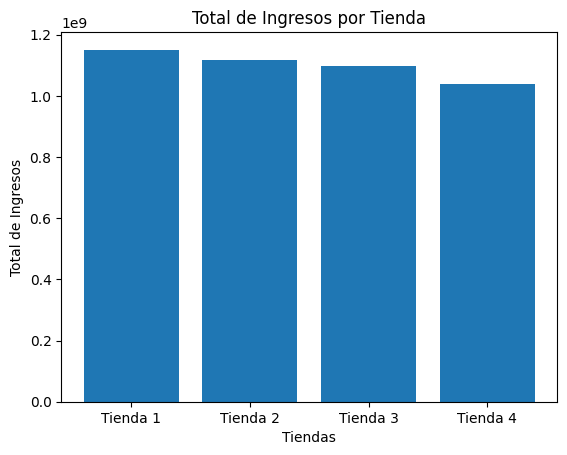

In [3]:
ingresos_tienda1 = tienda1['Precio'].sum()
ingresos_tienda2 = tienda2['Precio'].sum()
ingresos_tienda3 = tienda3['Precio'].sum()
ingresos_tienda4 = tienda4['Precio'].sum()

'''
OMITÍ ESTE CODIGO PUESTO QUE VISUALMENTE NO ES BUENO, NO SE APRECIA BIEN LA DATA.

print(f'Ingresos Tienda 1: ${ingresos_tienda1:,.2f}')
print(f'Ingresos Tienda 2: ${ingresos_tienda2:,.2f}')
print(f'Ingresos Tienda 3: ${ingresos_tienda3:,.2f}')
print(f'Ingresos Tienda 4: ${ingresos_tienda4:,.2f}')
'''

# se busca como tabularlo tipo tabla, aca se aprecia mejor.
from tabulate import tabulate

# Diccionario con los ingresos por tienda
tiendas = {
    "Tienda 1": ingresos_tienda1,
    "Tienda 2": ingresos_tienda2,
    "Tienda 3": ingresos_tienda3,
    "Tienda 4": ingresos_tienda4
}

# Ordenar ingresos de mayor a menor
tabla_tiendas = sorted(tiendas.items(), key=lambda x: x[1], reverse=True)

# Convertir a formato de tabla
print(tabulate(tabla_tiendas, headers=["Tienda", "Total de Ingresos en $"], floatfmt=",.0f"))

# Encontrar el mayor y el menor junto con la tienda asociada
tienda_mayor, mayor_ingreso = max(tiendas.items(), key=lambda x: x[1])
tienda_menor, menor_ingreso = min(tiendas.items(), key=lambda x: x[1])

print()
print(f'El mayor ingreso es de {tienda_mayor}: ${mayor_ingreso:,.0f}')
print(f'El menor ingreso es de {tienda_menor}: ${menor_ingreso:,.0f}')
print()

#Creamos una grafica simple, con imagen se entiende mejor.
import matplotlib.pyplot as plt

# Crear un gráfico de barras
plt.bar(tiendas.keys(), tiendas.values())

# Configurar etiquetas y título del gráfico
plt.xlabel('Tiendas')
plt.ylabel('Total de Ingresos')
plt.title('Total de Ingresos por Tienda')

plt.show()


# 2. Ventas por categoría

╒══════════════════════════╤═════════════╤═════════════╤═════════════╤═════════════╕
│ Categoría del Producto   │    Tienda 1 │    Tienda 2 │    Tienda 3 │    Tienda 4 │
╞══════════════════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ Artículos para el hogar  │  12,698,400 │  14,746,900 │  15,060,000 │  15,074,500 │
├──────────────────────────┼─────────────┼─────────────┼─────────────┼─────────────┤
│ Deportes y diversión     │  39,290,000 │  34,744,500 │  35,593,100 │  33,350,100 │
├──────────────────────────┼─────────────┼─────────────┼─────────────┼─────────────┤
│ Electrodomésticos        │ 363,685,200 │ 348,567,800 │ 329,237,900 │ 283,260,200 │
├──────────────────────────┼─────────────┼─────────────┼─────────────┼─────────────┤
│ Electrónicos             │ 429,493,500 │ 410,831,100 │ 410,775,800 │ 409,476,100 │
├──────────────────────────┼─────────────┼─────────────┼─────────────┼─────────────┤
│ Instrumentos musicales   │  91,299,000 │ 104,990,300 │  77,380,

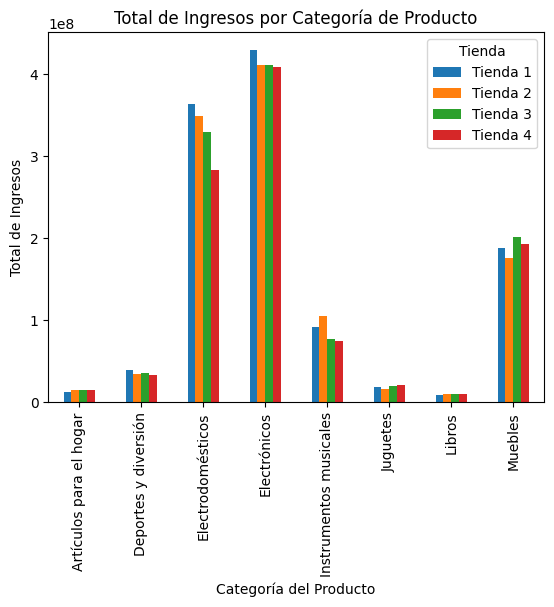

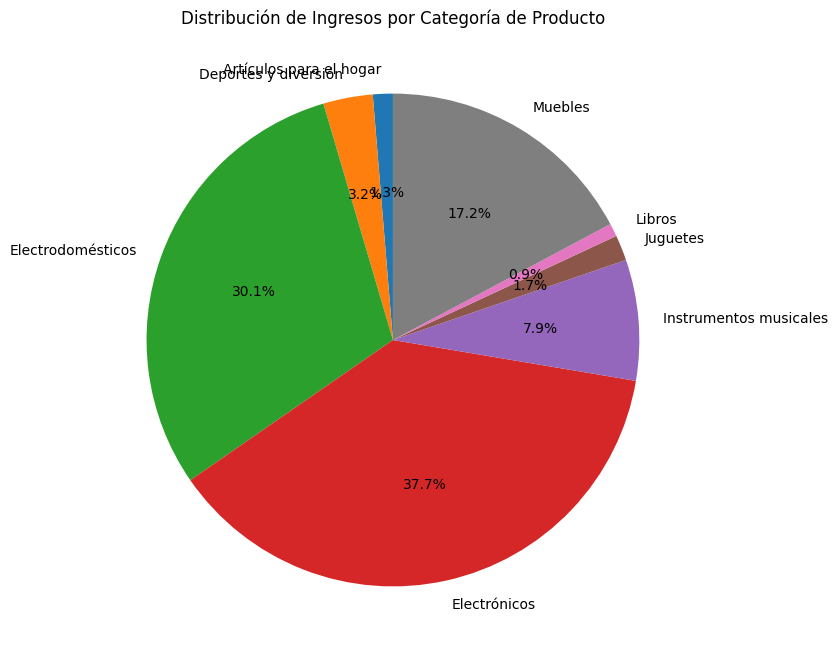

In [4]:
# Asignar el nombre de la tienda a cada DataFrame
tienda1["Tienda"] = "Tienda 1"
tienda2["Tienda"] = "Tienda 2"
tienda3["Tienda"] = "Tienda 3"
tienda4["Tienda"] = "Tienda 4"

# Concatenar todos los DataFrames en uno solo
dataframe_categoria = pd.concat([tienda1, tienda2, tienda3, tienda4])

# Crear la tabla pivote con la sumatoria de ventas por categoría por tienda
tabla_pivot = dataframe_categoria.pivot_table(index="Categoría del Producto", columns="Tienda", values="Precio", aggfunc="sum", fill_value=0)

tabla_formateada = tabulate(tabla_pivot, headers="keys", tablefmt="fancy_grid", floatfmt=",.0f")
print(tabla_formateada)

# Grafico
#import matplotlib.pyplot as plt

# Crear un gráfico de barras apiladas
tabla_pivot.plot(kind="bar", stacked=False, )
plt.xlabel('Categoría del Producto')
plt.ylabel('Total de Ingresos')
plt.title('Total de Ingresos por Categoría de Producto')

plt.show()
print()
print()

import matplotlib.pyplot as plt

# Crear un gráfico circular
plt.figure(figsize=(8, 8))
tabla_pivot.sum(axis=1).plot(kind="pie", autopct="%1.1f%%", startangle=90, legend=False)

plt.title("Distribución de Ingresos por Categoría de Producto")
plt.ylabel("")  # Ocultar la etiqueta del eje Y para mejor presentación
plt.show()



# 3. Calificación promedio de la tienda


Tienda      Calificación Promedio Ordenada
--------  --------------------------------
Tienda 3                            4.0483
Tienda 2                            4.0373
Tienda 4                            3.9958
Tienda 1                            3.9767

La mejor calificación es de la Tienda 3: 4.0483
La peor calificación es de la Tienda 1: 3.9767



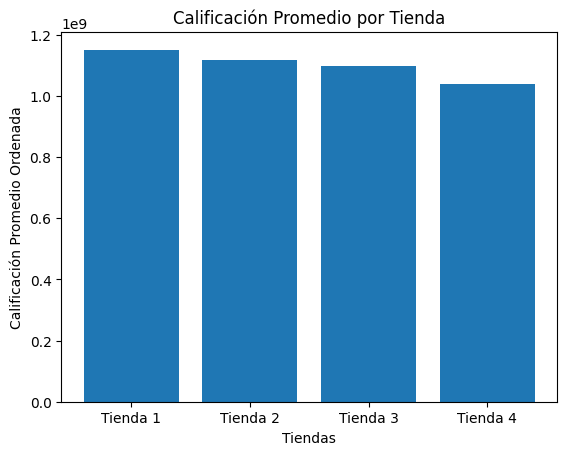

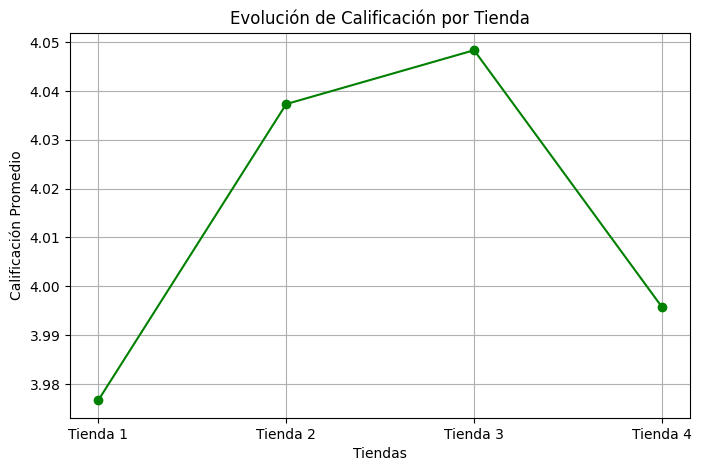

In [ ]:
#from tabulate import tabulate

# Diccionario con la calificación promedio por tienda
tiendas_calificacion = {
    "Tienda 1": tienda1["Calificación"].mean(),
    "Tienda 2": tienda2["Calificación"].mean(),
    "Tienda 3": tienda3["Calificación"].mean(),
    "Tienda 4": tienda4["Calificación"].mean(),
}

# Ordenar calificaciones de mayor a menor
tabla_tiendas_calificacion = sorted(tiendas_calificacion.items(), key=lambda x: x[1], reverse=True)

# Convertir a formato de tabla
print(tabulate(tabla_tiendas_calificacion, headers=["Tienda", "Calificación Promedio Ordenada"], floatfmt=".4f"))

# Encontrar la tienda con la mejor y peor calificación
tienda_calificacion_mayor, mayor_calificacion = max(tiendas_calificacion.items(), key=lambda x: x[1])
tienda_calificacion_menor, menor_calificacion = min(tiendas_calificacion.items(), key=lambda x: x[1])

print()
print(f'La mejor calificación es de la {tienda_calificacion_mayor}: {mayor_calificacion:.4f}')
print(f'La peor calificación es de la {tienda_calificacion_menor}: {menor_calificacion:.4f}')
print()

#Graficamos con un gráfico de barras
plt.bar(tiendas.keys(), tiendas.values())
plt.xlabel('Tiendas')
plt.ylabel('Calificación Promedio Ordenada')
plt.title('Calificación Promedio por Tienda')
plt.show()
print()

import matplotlib.pyplot as plt


print()

# Graficar con un gráfico de líneas
plt.figure(figsize=(8, 5))
plt.plot(tiendas_calificacion.keys(), tiendas_calificacion.values(), marker="o", linestyle="-", color="green")
plt.xlabel("Tiendas")
plt.ylabel("Calificación Promedio")
plt.title("Evolución de Calificación por Tienda")
plt.grid(True)
plt.show()


# 4a. Productos más y menos vendidos (Producto x valor)

╒════╤═════════════════════════════╤═══════════════════╕
│    │ Producto                    │   Total de Ventas │
╞════╪═════════════════════════════╪═══════════════════╡
│  0 │ TV LED UHD 4K               │       432,489,600 │
├────┼─────────────────────────────┼───────────────────┤
│  1 │ Iphone 15                   │       401,051,200 │
├────┼─────────────────────────────┼───────────────────┤
│  2 │ Refrigerador                │       384,937,400 │
├────┼─────────────────────────────┼───────────────────┤
│  3 │ Smart TV                    │       290,221,800 │
├────┼─────────────────────────────┼───────────────────┤
│  4 │ Lavadora de ropa            │       242,468,600 │
├────┼─────────────────────────────┼───────────────────┤
│  5 │ Lavavajillas                │       240,536,500 │
├────┼─────────────────────────────┼───────────────────┤
│  6 │ Tablet ABXY                 │       219,012,800 │
├────┼─────────────────────────────┼───────────────────┤
│  7 │ Secadora de ropa        

Text(0.5, 1.0, 'Total de Ventas por Producto')

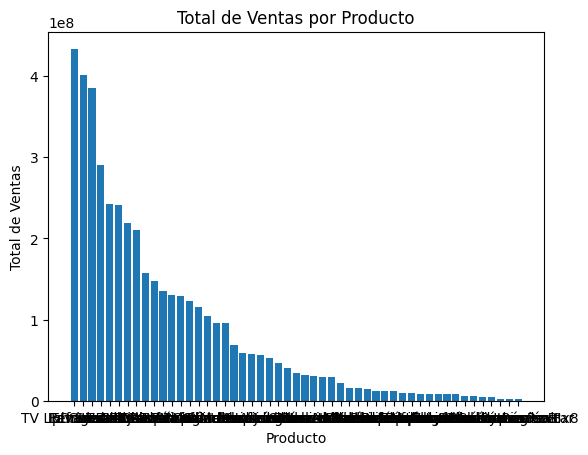

In [ ]:
# Asignar el nombre de la tienda a cada DataFrame
tienda1["Tienda"] = "Tienda 1"
tienda2["Tienda"] = "Tienda 2"
tienda3["Tienda"] = "Tienda 3"
tienda4["Tienda"] = "Tienda 4"

# Concatenar todos los DataFrames en uno solo
df = pd.concat([tienda1, tienda2, tienda3, tienda4])

# Agrupar por Producto y sumar ventas
ventas_por_producto = df.groupby("Producto")["Precio"].sum()

# Identificar el producto más vendido y el menos vendido
producto_mas_vendido = ventas_por_producto.idxmax()
mayor_ventas = ventas_por_producto.max()

producto_menos_vendido = ventas_por_producto.idxmin()
menor_ventas = ventas_por_producto.min()

# Crear una tabla ordenada con los productos
tabla_productos = ventas_por_producto.sort_values(ascending=False).reset_index()
tabla_productos.columns = ["Producto", "Total de Ventas"]

# Mostrar la tabla en formato tabulado
tabla_formateada = tabulate(tabla_productos, headers="keys", tablefmt="fancy_grid", floatfmt=",.0f")
print(tabla_formateada)

# Mostrar el producto más vendido y el menos vendido
print(f"\n📈 El producto más vendido es **{producto_mas_vendido}** con un total de ventas de ${mayor_ventas:,.0f}")
print(f"📉 El producto menos vendido es **{producto_menos_vendido}** con un total de ventas de ${menor_ventas:,.0f}")
print()

#Graficamos con un gráfico de barras
plt.bar(tabla_productos["Producto"], tabla_productos["Total de Ventas"])
plt.xlabel('Producto')
plt.ylabel('Total de Ventas')
plt.title('Total de Ventas por Producto')


## 4b. Productos más y menos vendidos (solo cantidad)

╒════╤═════════════════════════════╤════════════════════╕
│    │ Producto                    │   Cantidad Vendida │
╞════╪═════════════════════════════╪════════════════════╡
│  0 │ Mesa de noche               │                210 │
├────┼─────────────────────────────┼────────────────────┤
│  1 │ Carrito de control remoto   │                206 │
├────┼─────────────────────────────┼────────────────────┤
│  2 │ Microondas                  │                206 │
├────┼─────────────────────────────┼────────────────────┤
│  3 │ Batería                     │                203 │
├────┼─────────────────────────────┼────────────────────┤
│  4 │ Cama king                   │                201 │
├────┼─────────────────────────────┼────────────────────┤
│  5 │ Secadora de ropa            │                200 │
├────┼─────────────────────────────┼────────────────────┤
│  6 │ Modelado predictivo         │                200 │
├────┼─────────────────────────────┼────────────────────┤
│  7 │ Set de 

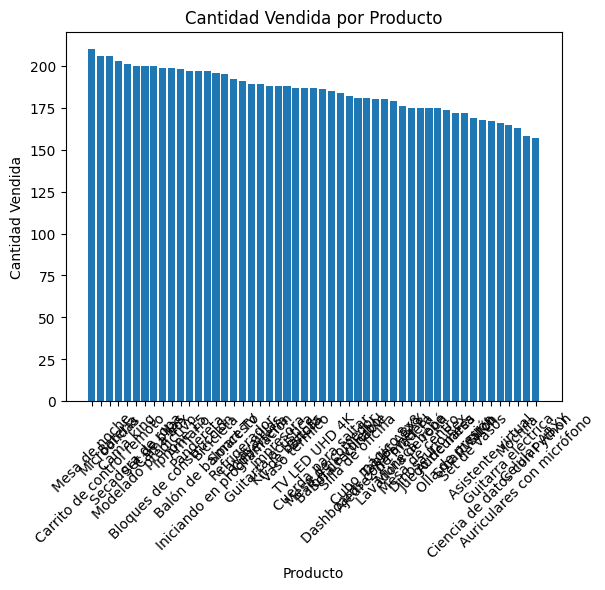

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate

# Asignar el nombre de la tienda a cada DataFrame
tienda1["Tienda"] = "Tienda 1"
tienda2["Tienda"] = "Tienda 2"
tienda3["Tienda"] = "Tienda 3"
tienda4["Tienda"] = "Tienda 4"

# Concatenar todos los DataFrames en uno solo
df = pd.concat([tienda1, tienda2, tienda3, tienda4])

# Contar la cantidad de ventas por producto
ventas_por_producto = df["Producto"].value_counts()

# Identificar el producto más vendido y el menos vendido
producto_mas_vendido = ventas_por_producto.idxmax()
mayor_ventas = ventas_por_producto.max()

producto_menos_vendido = ventas_por_producto.idxmin()
menor_ventas = ventas_por_producto.min()

# Crear una tabla ordenada con los productos por cantidad vendida
tabla_productos = ventas_por_producto.reset_index()
tabla_productos.columns = ["Producto", "Cantidad Vendida"]
tabla_productos = tabla_productos.sort_values(by="Cantidad Vendida", ascending=False)

# Mostrar la tabla en formato tabulado
tabla_formateada = tabulate(tabla_productos, headers="keys", tablefmt="fancy_grid", floatfmt=",.0f")
print(tabla_formateada)

# Mostrar el producto más vendido y el menos vendido
print(f"\n📈 El producto más vendido es **{producto_mas_vendido}** con {mayor_ventas:,} ventas.")
print(f"📉 El producto menos vendido es **{producto_menos_vendido}** con {menor_ventas:,} ventas.")
print()

# Graficamos con un gráfico de barras
plt.bar(tabla_productos["Producto"], tabla_productos["Cantidad Vendida"])
plt.xlabel('Producto')
plt.ylabel('Cantidad Vendida')
plt.title('Cantidad Vendida por Producto')
plt.xticks(rotation=45)  # Rotar etiquetas para mejor legibilidad
plt.show()

# 5. Envío promedio por tienda

Tienda      Envio Promedio
--------  ----------------
Tienda 1        26018.6096
Tienda 2        25216.2357
Tienda 3        24805.6804
Tienda 4        23459.4572

El envio más costoso es de la Tienda 1: $26018.6096
El envio menos costoso es de la Tienda 4: $23459.4572



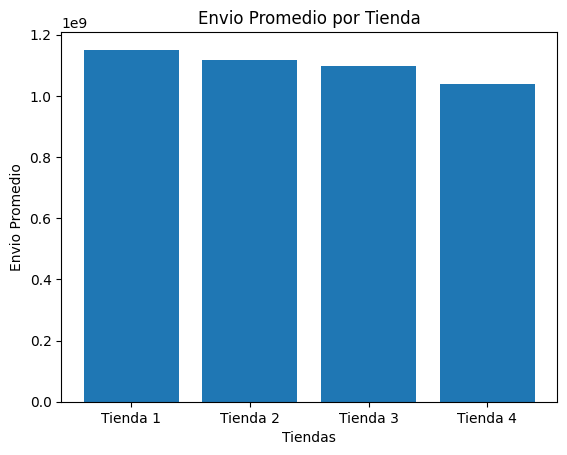

In [ ]:
#from tabulate import tabulate

# Diccionario con el costo de envio promedio por tienda
tiendas_envio = {
    "Tienda 1": tienda1["Costo de envío"].mean(),
    "Tienda 2": tienda2["Costo de envío"].mean(),
    "Tienda 3": tienda3["Costo de envío"].mean(),
    "Tienda 4": tienda4["Costo de envío"].mean(),
}

# Ordenar envio de mayor a menor
tabla_tiendas_envio = sorted(tiendas_envio.items(), key=lambda x: x[1], reverse=True)

# Convertir a formato de tabla
print(tabulate(tabla_tiendas_envio, headers=["Tienda", "Envio Promedio"], floatfmt=".4f"))

# Encontrar la tienda con la mejor y peor calificación
tienda_envio_mayor, mayor_envio = max(tiendas_envio.items(), key=lambda x: x[1])
tienda_envio_menor, menor_envio = min(tiendas_envio.items(), key=lambda x: x[1])

print()
print(f'El envio más costoso es de la {tienda_envio_mayor}: ${mayor_envio:.4f}')
print(f'El envio menos costoso es de la {tienda_envio_menor}: ${menor_envio:.4f}')
print()

#Graficamos con un gráfico de barras
plt.bar(tiendas.keys(), tiendas.values())
plt.xlabel('Tiendas')
plt.ylabel('Envio Promedio')
plt.title('Envio Promedio por Tienda')
plt.show()

# 6 Productos más costosos de enviar

╒════╤═════════════════════════════╤═════════════════════════╤════════════════════════╕
│    │ Producto                    │   Cantidad_Total_Ventas │   Costo_Promedio_Envio │
╞════╪═════════════════════════════╪═════════════════════════╪════════════════════════╡
│ 48 │ TV LED UHD 4K               │                     187 │                123,181 │
├────┼─────────────────────────────┼─────────────────────────┼────────────────────────┤
│ 25 │ Iphone 15                   │                     198 │                108,053 │
├────┼─────────────────────────────┼─────────────────────────┼────────────────────────┤
│ 39 │ Refrigerador                │                     191 │                107,097 │
├────┼─────────────────────────────┼─────────────────────────┼────────────────────────┤
│ 45 │ Smart TV                    │                     192 │                 80,421 │
├────┼─────────────────────────────┼─────────────────────────┼────────────────────────┤
│ 28 │ Lavadora de ropa         

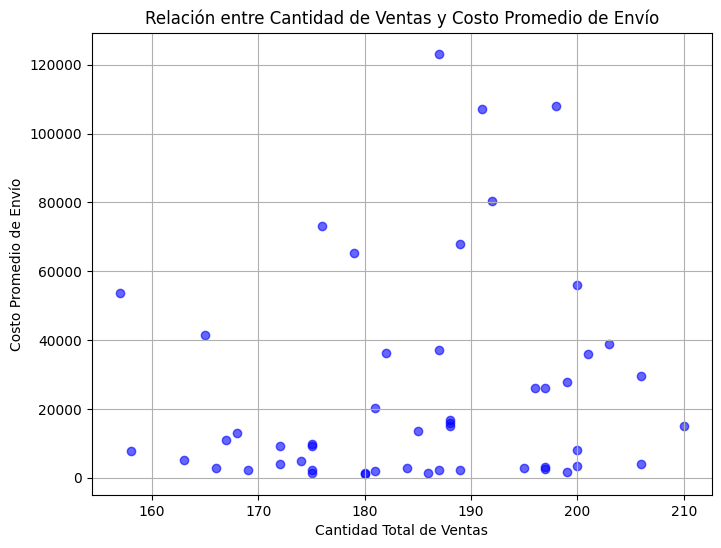

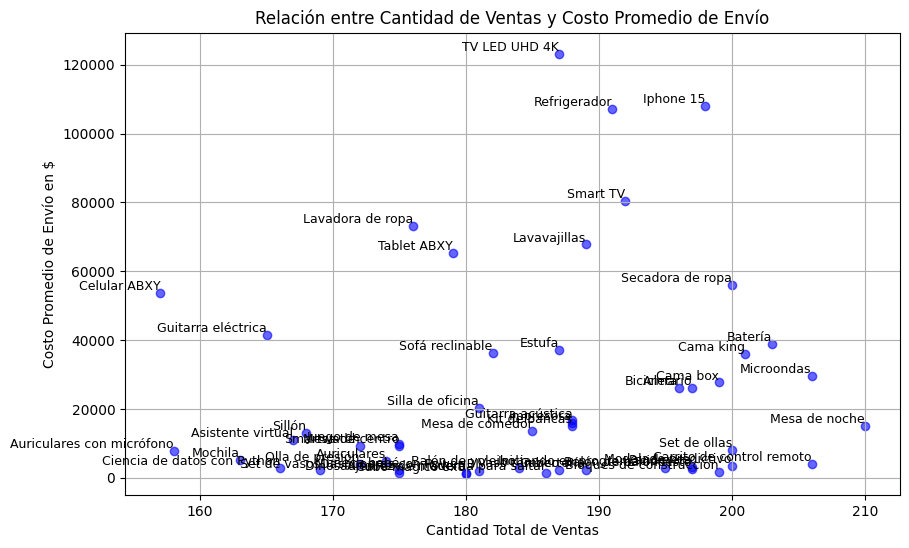

In [ ]:
df = pd.concat([tienda1, tienda2, tienda3, tienda4])

# Agrupar por Producto y calcular la cantidad total de ventas y el costo de envío promedio
productos_envio = df.groupby("Producto").agg(
    Cantidad_Total_Ventas=("Producto", "count"),
    Costo_Promedio_Envio=("Costo de envío", "mean")
).reset_index()

# Ordenar los productos por el costo de envío promedio de mayor a menor
productos_envio_ordenados = productos_envio.sort_values(by="Costo_Promedio_Envio", ascending=False)

# Mostrar la tabla en formato tabulado
tabla_formateada = tabulate(productos_envio_ordenados, headers="keys", tablefmt="fancy_grid", floatfmt=",.0f")
print(tabla_formateada)

# Crear gráfico de dispersión
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(productos_envio_ordenados["Cantidad_Total_Ventas"], productos_envio_ordenados["Costo_Promedio_Envio"], color="blue", alpha=0.6)
# Etiquetas y título
plt.xlabel("Cantidad Total de Ventas")
plt.ylabel("Costo Promedio de Envío")
plt.title("Relación entre Cantidad de Ventas y Costo Promedio de Envío")
plt.grid(True)
plt.show()

print()

import matplotlib.pyplot as plt

# Crear gráfico de dispersión
plt.figure(figsize=(10, 6))
plt.scatter(productos_envio_ordenados["Cantidad_Total_Ventas"], productos_envio_ordenados["Costo_Promedio_Envio"], color="blue", alpha=0.6)

# Agregar etiquetas con los nombres de los productos
for i, row in productos_envio_ordenados.iterrows():
    plt.text(row["Cantidad_Total_Ventas"], row["Costo_Promedio_Envio"], row["Producto"], fontsize=9, ha="right", va="bottom")

# Etiquetas y título
plt.xlabel("Cantidad Total de Ventas")
plt.ylabel("Costo Promedio de Envío en $")
plt.title("Relación entre Cantidad de Ventas y Costo Promedio de Envío")
plt.grid(True)

# Mostrar el gráfico
plt.show()
